<a href="https://colab.research.google.com/github/mateuszlampert/agh-stochastic-ml/blob/sol%2Flab2/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
from abc import ABC, abstractmethod

class Problem(ABC):
    @abstractmethod
    def __call__(self, x: np.ndarray) -> float:
        """Compute the function value at point x."""
        raise NotImplementedError

    @abstractmethod
    def grad(self, x: np.ndarray) -> np.ndarray:
        """Compute the gradient at point x."""
        raise NotImplementedError

class Sphere(Problem):
    def __call__(self, x: np.ndarray) -> float:
        return np.sum(x**2)

    def grad(self, x: np.ndarray) -> np.ndarray:
        return 2 * x

class Rosenbrock(Problem):
    def __call__(self, x: np.ndarray) -> float:
        return np.sum(100.0 * (x[1:] - x[:-1]**2)**2 + (1 - x[:-1])**2)

    def grad(self, x: np.ndarray) -> np.ndarray:
        grad = np.zeros_like(x)
        n = x.size
        grad[0] = -400 * x[0] * (x[1] - x[0]**2) - 2 * (1 - x[0])
        for i in range(1, n - 1):
            grad[i] = 200 * (x[i] - x[i-1]**2) - 400 * x[i] * (x[i+1] - x[i]**2) - 2 * (1 - x[i])
        grad[-1] = 200 * (x[-1] - x[-2]**2)
        return grad

class Rastrigin(Problem):
    def __call__(self, x: np.ndarray) -> float:
        A = 10
        n = x.size
        return A * n + np.sum(x**2 - A * np.cos(2 * np.pi * x))

    def grad(self, x: np.ndarray) -> np.ndarray:
        A = 10
        return 2 * x + 2 * np.pi * A * np.sin(2 * np.pi * x)


In [2]:
import matplotlib.pyplot as plt
import plotly.graph_objects as go

def prepare_mesh_grid(
    problem: Problem,
    bounds: tuple[float, float] = (-5.0, 5.0),
    grid_size: int = 50,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    x_vals = np.linspace(bounds[0], bounds[1], grid_size)
    y_vals = np.linspace(bounds[0], bounds[1], grid_size)
    X, Y = np.meshgrid(x_vals, y_vals)

    Z = np.zeros_like(X)
    for i in range(grid_size):
        for j in range(grid_size):
            xy = np.array([X[i, j], Y[i, j]])
            Z[i, j] = problem(xy)

    return X, Y, Z, x_vals, y_vals


def plot_3d_surface(
    problem: Problem,
    grid_size: int = 50,
):
    X, Y, Z, _, _ = prepare_mesh_grid(problem=problem, grid_size=grid_size)

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")
    surf = ax.plot_surface(X, Y, Z, cmap="viridis", edgecolor="none")

    ax.set_title(problem.__class__.__name__)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("f(x, y)")

    fig.colorbar(surf, shrink=0.5, aspect=10)
    plt.tight_layout()
    plt.show()

def plot_contour_and_paths(
    problem: Problem,
    paths: list[np.ndarray],
    grid_size: int = 200,
    title: str = "",
):
    """
    Create an interactive contour plot of a 2D function and overlay multiple optimization paths.

    Args:
        problem: An instance of a Problem class.
        paths: List of numpy arrays; each array is of shape (epochs, 2) containing an optimization trajectory.
        title: Title for the plot.
    """
    _, _, Z, x_vals, y_vals = prepare_mesh_grid(problem, grid_size=grid_size)

    fig = go.Figure(
        data=go.Contour(
            x=x_vals,
            y=y_vals,
            z=Z,
            colorscale="Viridis",
            contours=dict(showlines=False),
            colorbar=dict(title="Function Value"),
        )
    )

    colors = ['red', 'blue', 'green', 'purple', 'orange', 'cyan', 'magenta', 'yellow', 'pink', 'brown']

    for idx, path in enumerate(paths):
        color_idx = idx % len(colors)
        fig.add_trace(
            go.Scatter(
                x=path[:, 0],
                y=path[:, 1],
                mode="lines+markers",
                marker=dict(size=4),
                line=dict(width=2, color=colors[color_idx]),
                name=f"Run {idx+1}",
                showlegend=True,
            )
        )

    fig.update_layout(
        title=title, xaxis_title="x", yaxis_title="y", width=800, height=700,
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
    )

    fig.show()

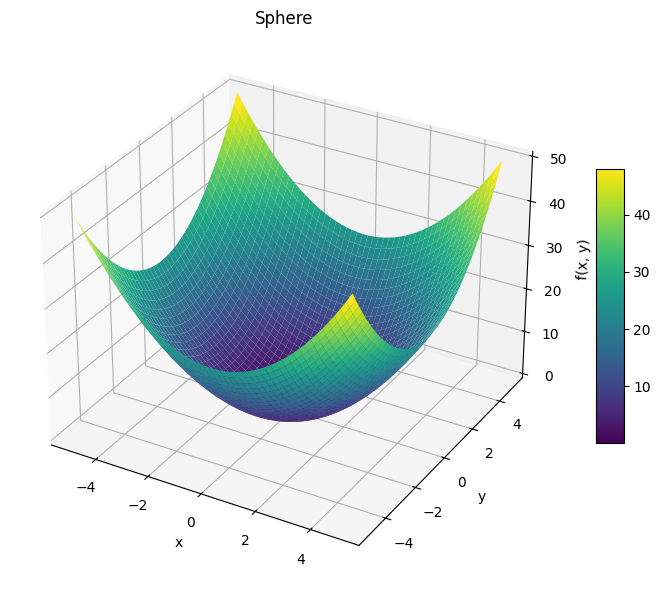

In [3]:
sphere = Sphere()
plot_3d_surface(problem=sphere)

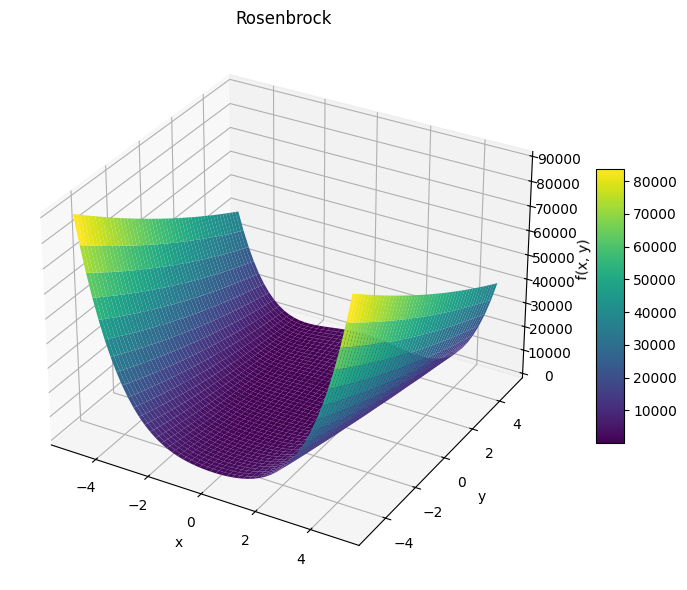

In [4]:
rosenbrock = Rosenbrock()
plot_3d_surface(rosenbrock)

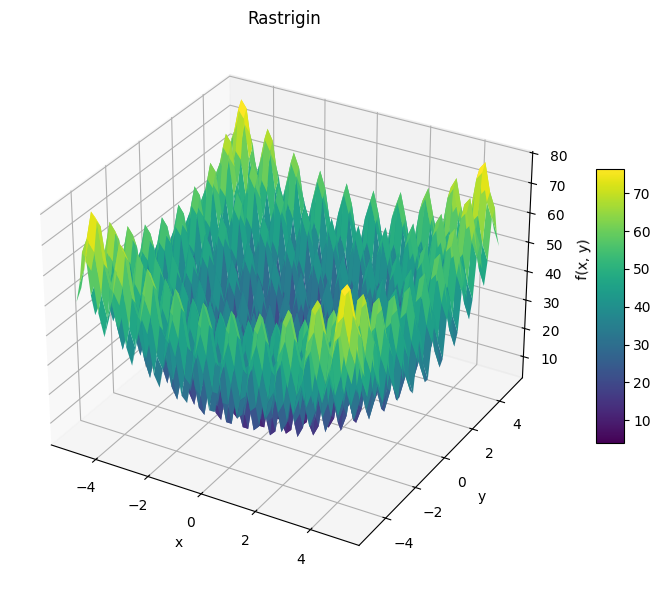

In [5]:
rastrigin = Rastrigin()
plot_3d_surface(problem=rastrigin)

In [7]:
def momentum(
    problem: Problem,
    initial_solution: np.ndarray,
    alpha: float,
    beta: float,
    number_of_epochs: int,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    dim = initial_solution.shape[0]
    v = np.zeros_like(initial_solution)
    w = initial_solution

    positions = np.ndarray(shape=(number_of_epochs, dim))
    function_values = np.ndarray(shape=(number_of_epochs))
    velocity_norms = np.ndarray(shape=(number_of_epochs))

    positions[0] = w
    function_values[0] = problem(w)
    velocity_norms[0] = np.linalg.norm(v)

    for i in range(1, number_of_epochs):
      v = beta * v + alpha * problem.grad(w)
      w = w - v

      positions[i] = w
      function_values[i] = problem(w)
      velocity_norms[i] = np.linalg.norm(v)

    return positions, function_values, velocity_norms

In [38]:
sphere = Sphere()

_sphere_positions, _sphere_function_values, _sphere_velocity_norms = momentum(
    problem=sphere,
    initial_solution=np.array([2.0, 2.0]),
    alpha=0.01,
    beta=0.9,
    number_of_epochs=100
)

sphere_positions = [_sphere_positions]
sphere_function_values=[_sphere_function_values]
sphere_velocity_norms=[_sphere_velocity_norms]

In [39]:
import plotly.express as px

fig1 = px.line(
  sphere_function_values[0],
  title="Function values vs. epoch",
)
fig2 = px.line(
  sphere_velocity_norms[0],
  title="Velocity norm vs. epoch"
)

fig1.show()
fig2.show()

In [40]:
plot_contour_and_paths(problem=sphere, paths=sphere_positions)

In [27]:
alphas = [0.001, 0.0001]

rosenbrock = Rosenbrock()
rosenbrock_positions = []
rosenbrock_function_values = []
rosenbrock_velocity_norms = []

for alpha in alphas:
  _positions, _function_values, _velocity_norms = momentum(
      problem=rosenbrock,
      initial_solution=np.array([2.0, 2.0]),
      alpha=alpha,
      beta=0.9,
      number_of_epochs=100
  )

  rosenbrock_positions.append(_positions)
  rosenbrock_function_values.append(_function_values)
  rosenbrock_velocity_norms.append(_velocity_norms)

In [29]:
import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Scatter(y=rosenbrock_function_values[0], name="alpha=0.001"))
fig.add_trace(go.Scatter(y=rosenbrock_function_values[1], name="alpha=0.0001"))

In [30]:
import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Scatter(y=rosenbrock_velocity_norms[0], name="alpha=0.001"))
fig.add_trace(go.Scatter(y=rosenbrock_velocity_norms[1], name="alpha=0.0001"))

In [37]:
plot_contour_and_paths(problem=rastrigin, paths=rosenbrock_positions)

In [31]:
alphas = [0.001, 0.0001]

rastrigin = Rastrigin()
rastrigin_positions = []
rastrigin_function_values = []
rastrigin_velocity_norms = []

for alpha in alphas:
  _positions, _function_values, _velocity_norms = momentum(
      problem=rastrigin,
      initial_solution=np.array([2.0, 2.0]),
      alpha=alpha,
      beta=0.9,
      number_of_epochs=100
  )

  rastrigin_positions.append(_positions)
  rastrigin_function_values.append(_function_values)
  rastrigin_velocity_norms.append(_velocity_norms)

In [32]:
import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Scatter(y=rastrigin_function_values[0], name="alpha=0.001"))
fig.add_trace(go.Scatter(y=rastrigin_function_values[1], name="alpha=0.0001"))

In [33]:
import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Scatter(y=rastrigin_velocity_norms[0], name="alpha=0.001"))
fig.add_trace(go.Scatter(y=rastrigin_velocity_norms[1], name="alpha=0.0001"))

In [36]:
plot_contour_and_paths(problem=rastrigin, paths=rastrigin_positions)

In [ ]:
alpha = 1e-4
initial_solution = np.ndarray([2.0, 2.0])
number_of_epochs = 100
betas = [0.5, 0.75, 0.9, 0.95, 0.99]

rosenbrock = Rosenbrock()

In [ ]:
def adam(
    problem: Problem,
    initial_solution: np.ndarray,
    alpha: float,
    beta1: float,
    beta2: float,
    number_of_epochs: int,
    epsilon: float = 1e-8
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    dim = initial_solution.shape[0]
    v = np.zeros_like(initial_solution)
    m = np.zeros_like(initial_solution)
    w = initial_solution

    for i in range(number_of_epochs):
      m = beta1 * m + (1 - beta1) * problem.grad(w)
      v = beta2 * v + (1 - beta2) * problem.grad(w) ** 2
      m_hat = m / (1 - beta1 ** i)
      v_hat = v / (1 - beta2 ** i)

      w = w - (alpha * m_hat / np.sqrt())
